In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [4]:
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]

In [5]:
image_error_cut

array([[0.0303987 , 0.02912354, 0.02480921, ..., 0.0067154 , 0.00691563,
        0.00693766],
       [0.03006888, 0.02813161, 0.02885036, ..., 0.00677515, 0.0061732 ,
        0.00663774],
       [0.03166641, 0.02917927, 0.03076373, ..., 0.00689471, 0.00661363,
        0.00693721],
       ...,
       [0.02708479, 0.02681352, 0.03034172, ..., 0.00661501, 0.00649011,
        0.00683801],
       [0.02696249, 0.02753854, 0.02932177, ..., 0.00645496, 0.00637915,
        0.00649103],
       [0.02817379, 0.02815345, 0.02910345, ..., 0.00675251, 0.00685232,
        0.00682028]], dtype='>f4')

Text(0.5, 0, 'wavelenght')

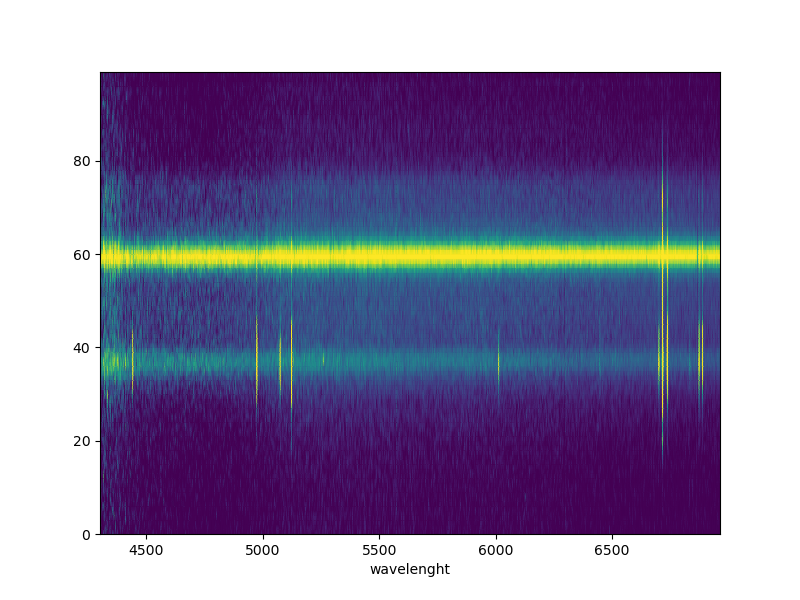

In [6]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.figure(figsize=(8,6))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

## Redshift or the lines in air

In [7]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [8]:
l_NII

6739.6754

## Continuum

Text(0.5, 1.0, 'Continuum 3')

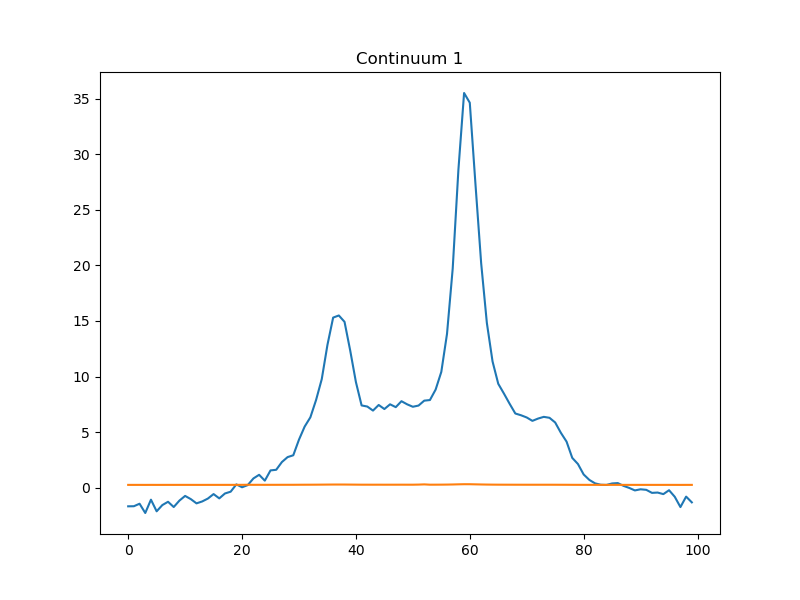

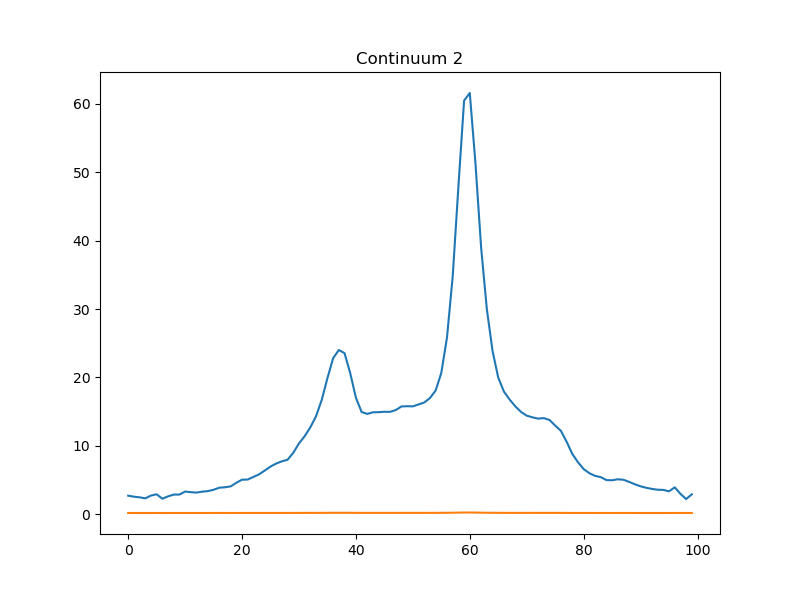

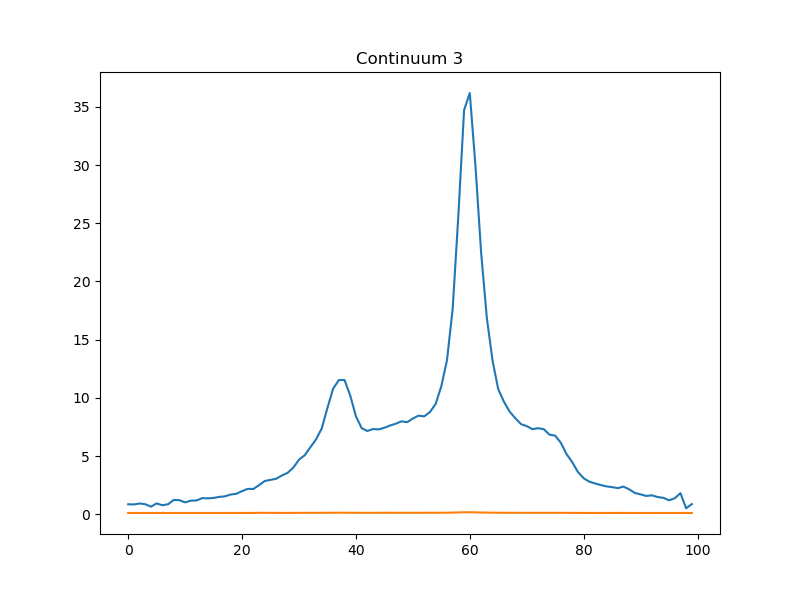

In [9]:
mask_continuum_1 = (wavelenghts > 4500)*(wavelenghts < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

mask_continuum_2 = (wavelenghts > 5300)*(wavelenghts < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

mask_continuum_3 = (wavelenghts > 6400)*(wavelenghts < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

## Sky lines

In [10]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[55:155, 0:1800]

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


Text(0.5, 36.72222222222221, 'wavelenght')

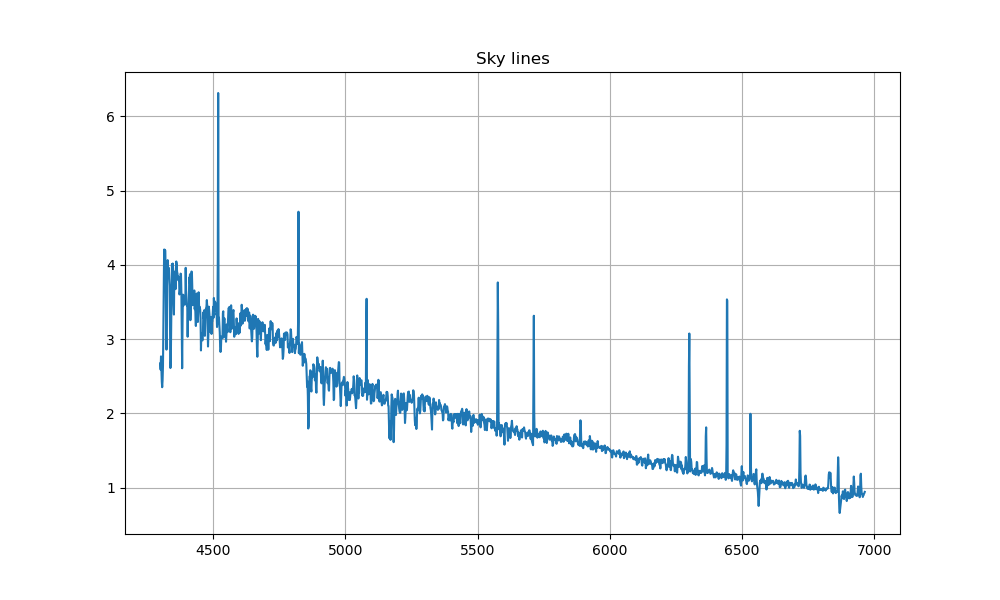

In [11]:
mask_sky = (y > 15)*(y < 25)
image_sky = image_cut2[mask_sky, :]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wavelenghts, radial_profile_sky)
#x_interval = np.arange(4300, 4300+1800*1.48, 250)
#plt.xticks(x_interval)
plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

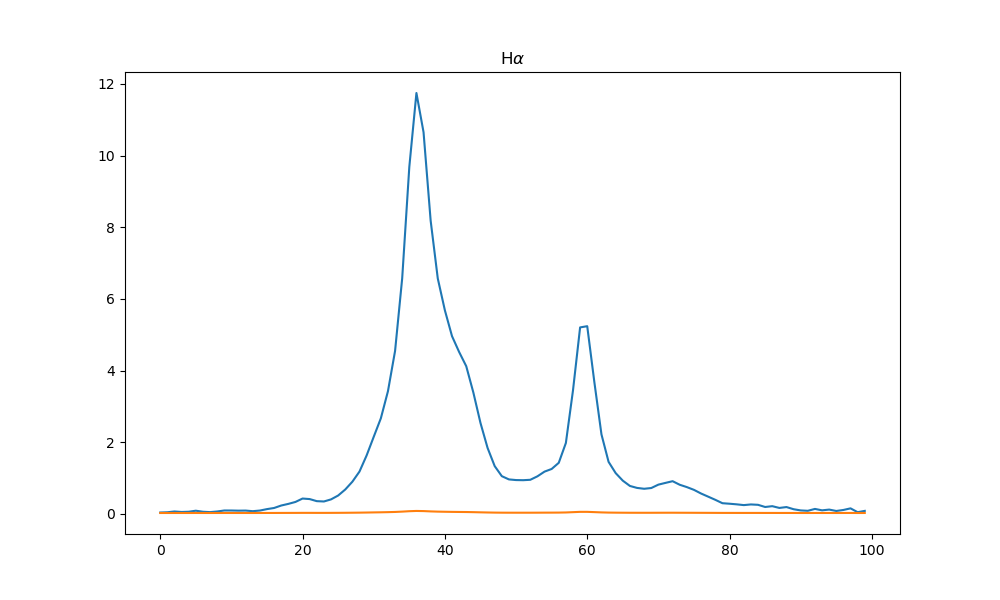

In [12]:
#Ogni punto del flusso è il risultato della media di 20 lunghezze d'onda pesate
mask_HA = (wavelenghts > l_HA-8)*(wavelenghts < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [13]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (50, 70),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 90.97591382074808
differential_evolution step 2: f(x)= 90.97591382074808
differential_evolution step 3: f(x)= 90.97591382074808
differential_evolution step 4: f(x)= 86.73790985881432
differential_evolution step 5: f(x)= 86.73790985881432
differential_evolution step 6: f(x)= 85.26785533024331
differential_evolution step 7: f(x)= 66.45834735167811
differential_evolution step 8: f(x)= 66.45834735167811
differential_evolution step 9: f(x)= 66.45834735167811
differential_evolution step 10: f(x)= 59.9835526709248
differential_evolution step 11: f(x)= 59.9835526709248
differential_evolution step 12: f(x)= 35.39821909202464
differential_evolution step 13: f(x)= 35.39821909202464
differential_evolution step 14: f(x)= 35.39821909202464
differential_evolution step 15: f(x)= 35.39821909202464
differential_evolution step 16: f(x)= 35.39821909202464
differential_evolution step 17: f(x)= 19.589846461330353
differential_evolution step 18: f(x)= 19.589846461330353
d

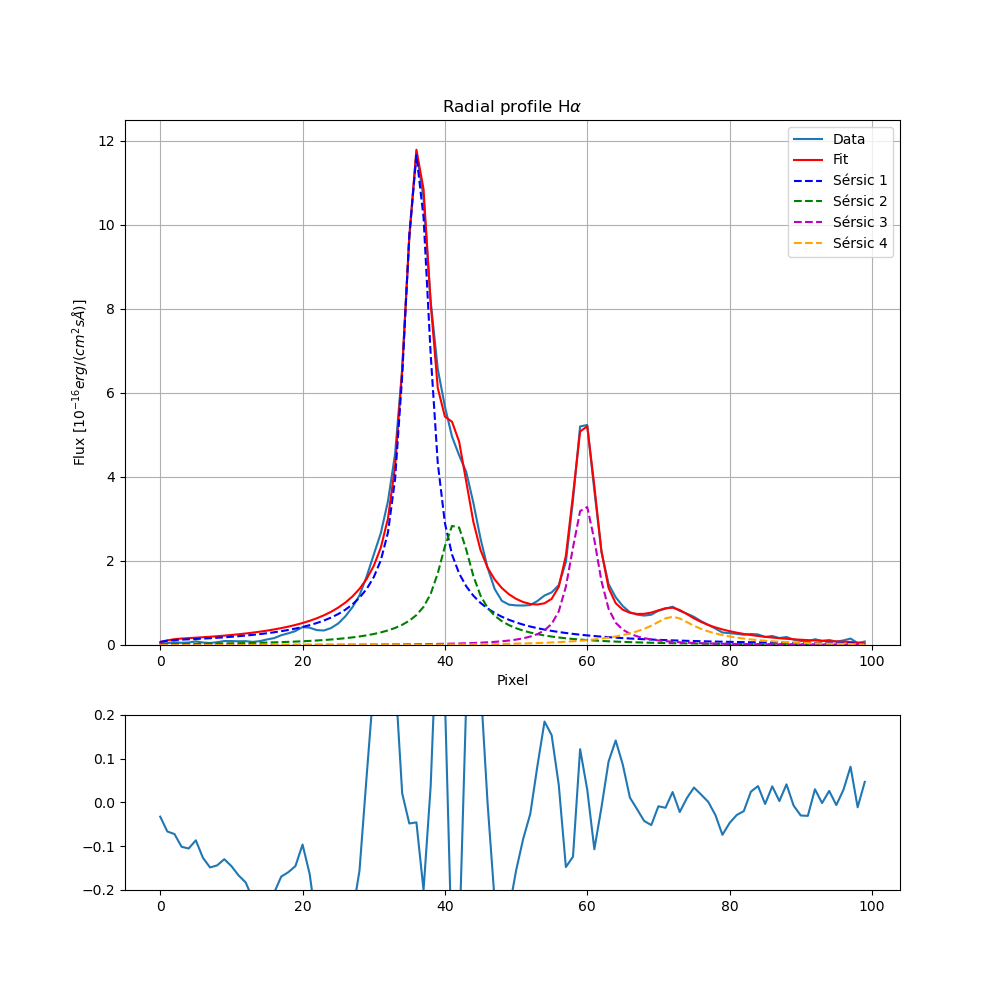

In [14]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

plt.savefig('Radial_profile_Halpha_diff')

In [15]:
params_curve_HA, covariance_HA = curve_fit(model_convolved, x_axes, radial_profile_HA, p0=result.x, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0_HA = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0_HA[i] = params_curve_HA[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_HA)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0_HA[i]:.4f}")

print(np.sqrt(np.diag(covariance_HA)))
#print(infodict.fvec**2)
chi2_HA = np.sum((((radial_profile_HA - model_convolved(x_axes, *params_curve_HA)) / radial_profile_error_HA)**2))
dof_HA = len(radial_profile_HA) - len(params_curve_HA)
chi2_reduced_HA = chi2_HA / dof_HA
print(chi2_reduced_HA)

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0_HA, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Halpha_fit.csv", index= False, float_format='%.4f')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_13352\621409132.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_13352\621409132.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.4935, r_e=12.6298, n=2.3362, x_0=36.0890
Sérsic 2: I_e=0.6151, r_e=5.2282, n=1.1434, x_0=41.6753
Sérsic 3: I_e=0.0661, r_e=19.4125, n=3.5469, x_0=59.5634
Sérsic 4: I_e=0.0576, r_e=22.7025, n=1.5934, x_0=72.2781
[1.78379913e-01 3.14713461e+00 2.80421036e-01 5.22048402e-02
 2.44858199e-01 1.68207972e+00 2.93229234e-01 2.06330807e-01
 4.85509847e-01 9.83284212e+01 7.68024648e+00 1.64948950e-03
 4.65243196e-02 2.33397337e+01 5.68610143e-01 4.61485448e-01]
10.092655987174899


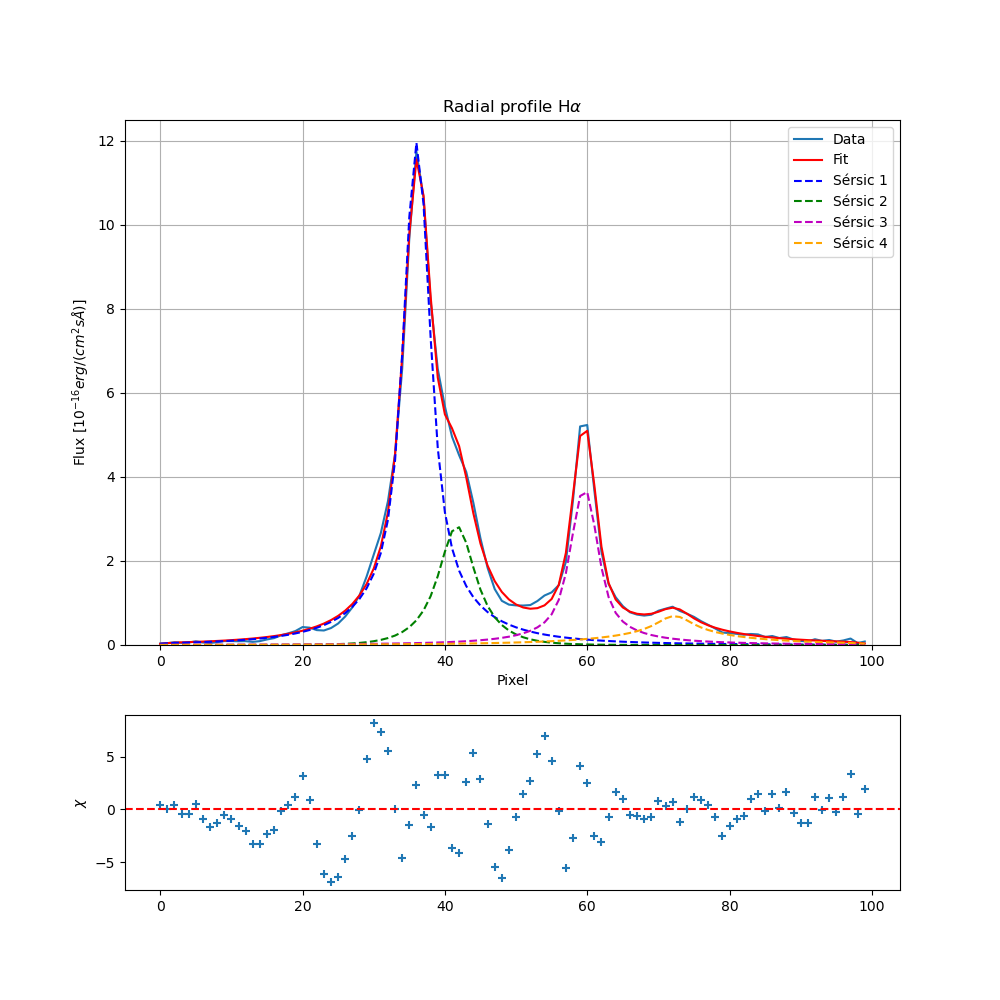

In [16]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_HA)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)
#ax[0].tight_layout()

ax[1].scatter(x_axes, (radial_profile_HA - y_fit)/radial_profile_error_HA, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')

plt.savefig('Radial_profile_Halpha_curve')

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

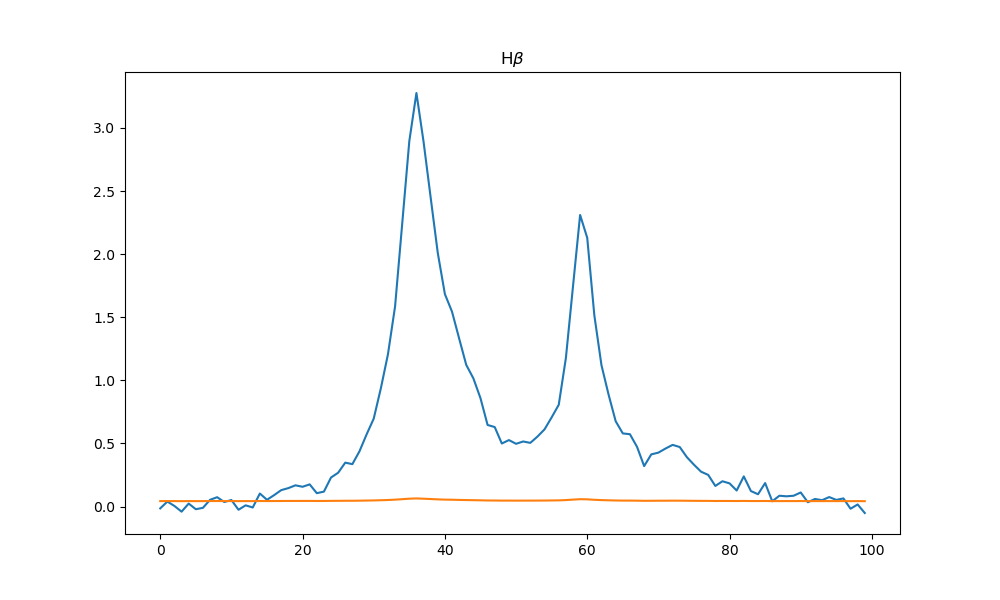

In [57]:
mask_HB = (wavelenghts > l_HB-8)*(wavelenghts < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [58]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3.886743642444371
differential_evolution step 2: f(x)= 3.886743642444371
differential_evolution step 3: f(x)= 3.886743642444371
differential_evolution step 4: f(x)= 3.886743642444371
differential_evolution step 5: f(x)= 3.7808758889147667
differential_evolution step 6: f(x)= 3.1589112954910648
differential_evolution step 7: f(x)= 3.1589112954910648
differential_evolution step 8: f(x)= 2.4782734002198032
differential_evolution step 9: f(x)= 2.4782734002198032
differential_evolution step 10: f(x)= 2.4782734002198032
differential_evolution step 11: f(x)= 2.4782734002198032
differential_evolution step 12: f(x)= 2.4782734002198032
differential_evolution step 13: f(x)= 2.214070035136886
differential_evolution step 14: f(x)= 2.214070035136886
differential_evolution step 15: f(x)= 2.214070035136886
differential_evolution step 16: f(x)= 2.214070035136886
differential_evolution step 17: f(x)= 2.214070035136886
differential_evolution step 18: f(x)= 2.214070035

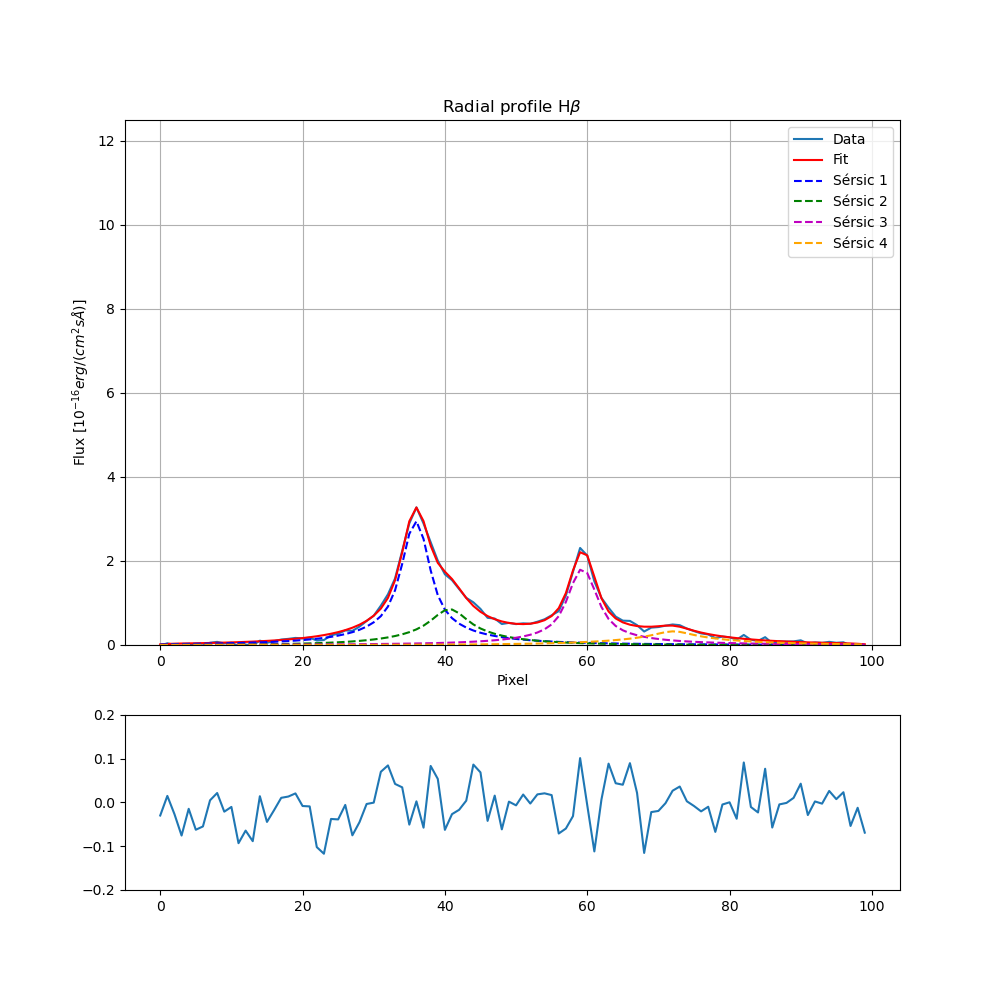

In [59]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].plot(x_axes, radial_profile_HB - y_fit)
ax[1].set_ylim(-0.2, 0.2)
plt.savefig('Radial_profile_Hbeta_kernel')

In [60]:
params_curve_HB, covariance_HB = curve_fit(model_convolved, x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_HB[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_HB)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("HBeta_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_HB)))
#print(infodict.fvec**2)
chi2_HB = np.sum((((radial_profile_HB - model_convolved(x_axes, *params_curve_HB)) / radial_profile_error_HB)**2))
dof_HB = len(radial_profile_HB) - len(params_curve_HB)
chi2_reduced_HB = chi2_HB / dof_HB
print(chi2_reduced_HB)

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_8860\4061730068.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_8860\4061730068.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.2035, r_e=10.9438, n=1.8886, x_0=35.8392
Sérsic 2: I_e=0.2429, r_e=6.3354, n=0.7897, x_0=40.5752
Sérsic 3: I_e=0.0326, r_e=31.9307, n=3.0564, x_0=59.3653
Sérsic 4: I_e=0.0232, r_e=22.2787, n=1.6900, x_0=72.3403
[1.15276016e-01 4.11686454e+00 3.79045130e-01 9.34876539e-02
 1.00170567e-01 1.43678386e+00 2.22433353e-01 8.85422892e-01
 9.54881536e-02 7.34217856e+01 2.50742230e+00 1.10668740e-03
 3.09121655e-02 3.59765475e+01 9.06312436e-01 4.20786492e-01]
0.941768716164778


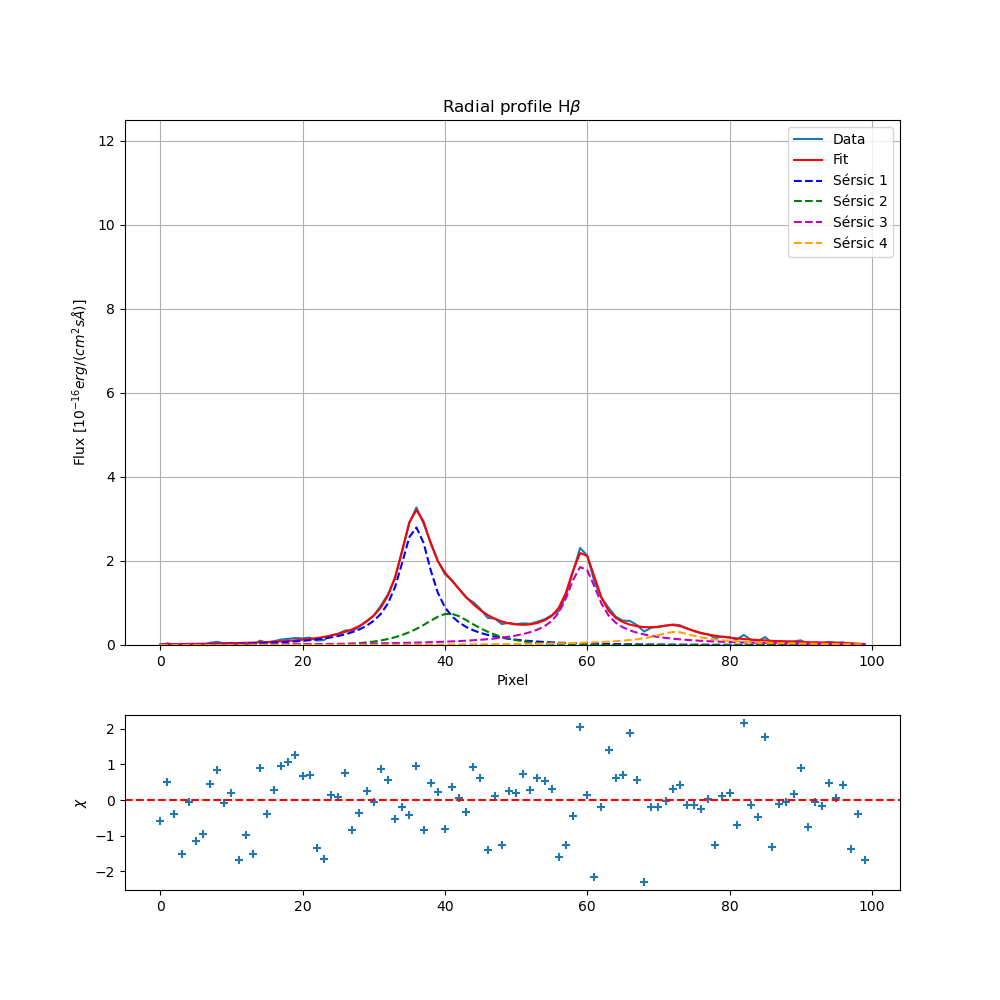

In [61]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_HB)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].scatter(x_axes, (radial_profile_HB - y_fit)/radial_profile_error_HB, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

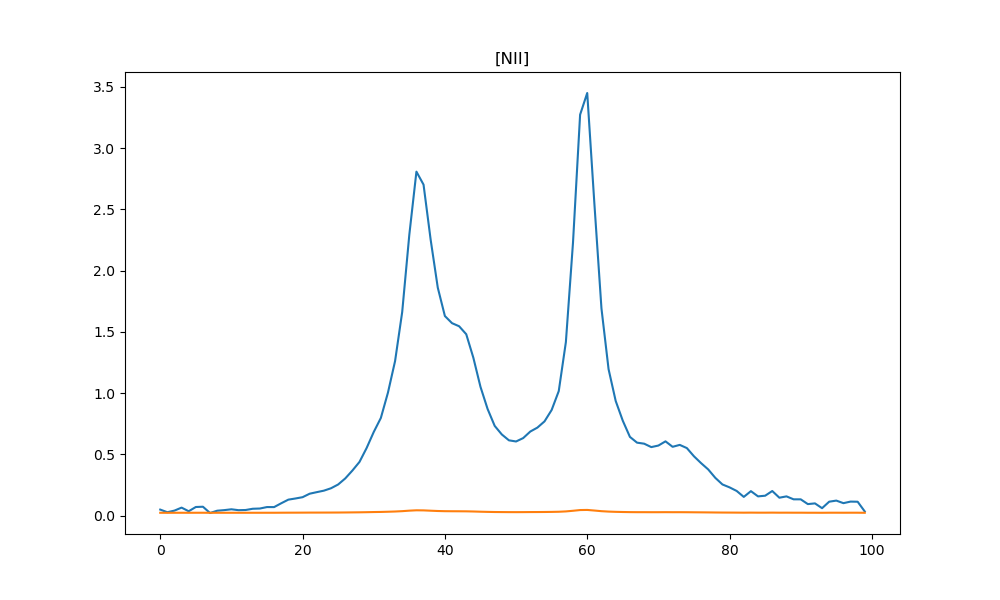

In [62]:
mask_NII = (wavelenghts > l_NII-8)*(wavelenghts < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [63]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 15.93767687791254
differential_evolution step 2: f(x)= 9.036463027633415
differential_evolution step 3: f(x)= 3.9597287103292635
differential_evolution step 4: f(x)= 3.9597287103292635
differential_evolution step 5: f(x)= 3.9597287103292635
differential_evolution step 6: f(x)= 3.9597287103292635
differential_evolution step 7: f(x)= 3.9597287103292635
differential_evolution step 8: f(x)= 3.9597287103292635
differential_evolution step 9: f(x)= 3.9597287103292635
differential_evolution step 10: f(x)= 3.9597287103292635
differential_evolution step 11: f(x)= 2.617440388692811
differential_evolution step 12: f(x)= 2.617440388692811
differential_evolution step 13: f(x)= 2.617440388692811
differential_evolution step 14: f(x)= 2.617440388692811
differential_evolution step 15: f(x)= 2.581578493391993
differential_evolution step 16: f(x)= 2.3265478618932547
differential_evolution step 17: f(x)= 2.260425285456778
differential_evolution step 18: f(x)= 1.62467691

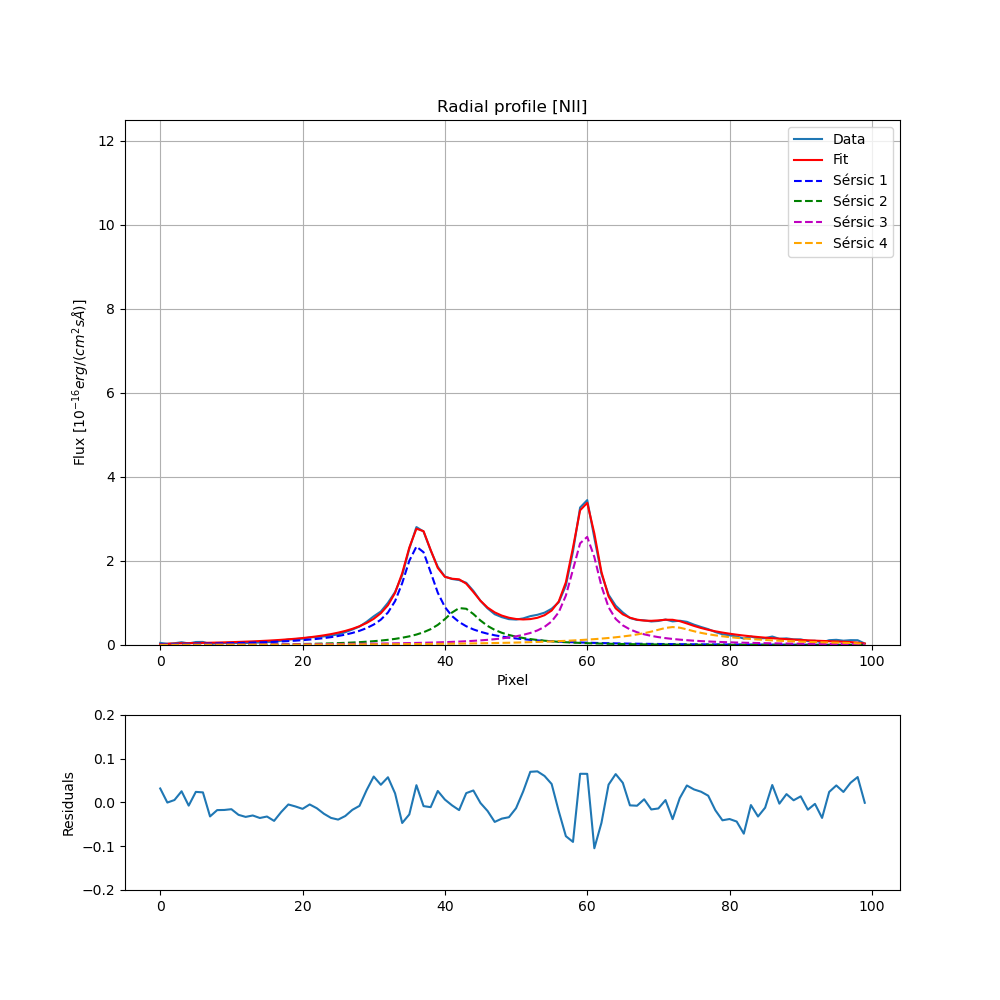

In [64]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].plot(x_axes, radial_profile_NII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')
plt.savefig('Radial_profile_NII_kernel')

In [65]:
params_curve_NII, covariance_NII = curve_fit(model_convolved, x_axes, radial_profile_NII, p0=result.x, sigma = radial_profile_error_NII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_NII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_NII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("NII_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_NII)))
#print(infodict.fvec**2)
chi2_NII = np.sum((((radial_profile_NII - model_convolved(x_axes, *params_curve_NII)) / radial_profile_error_NII)**2))
dof_NII = len(radial_profile_NII) - len(params_curve_NII)
chi2_reduced_NII = chi2_NII / dof_NII
print(chi2_reduced_NII)

Sérsic 1: I_e=0.1049, r_e=16.7944, n=2.2718, x_0=36.2777
Sérsic 2: I_e=0.0987, r_e=11.2793, n=1.5238, x_0=42.3872
Sérsic 3: I_e=0.0304, r_e=32.3415, n=3.6050, x_0=59.6624
Sérsic 4: I_e=0.0433, r_e=24.9500, n=1.4144, x_0=72.3050
[5.22508914e-02 7.25995861e+00 3.45664993e-01 5.74083578e-02
 7.56926112e-02 8.55659632e+00 5.23608640e-01 1.79340017e-01
 1.07216973e-01 8.44155567e+01 3.24510625e+00 2.74079273e-04
 1.91632285e-02 1.51802752e+01 3.09228563e-01 3.56891698e-01]
1.6111190959129906


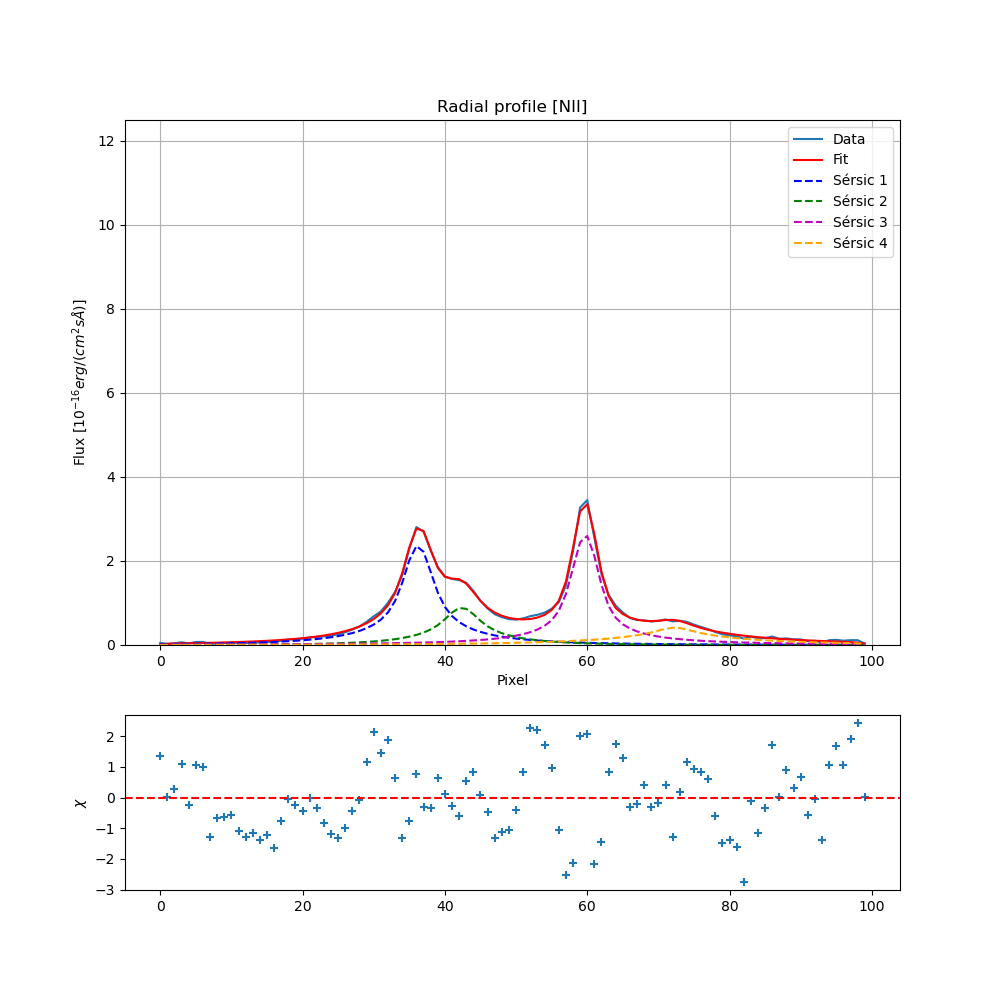

In [66]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_NII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].scatter(x_axes, (radial_profile_NII - y_fit)/radial_profile_error_NII, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

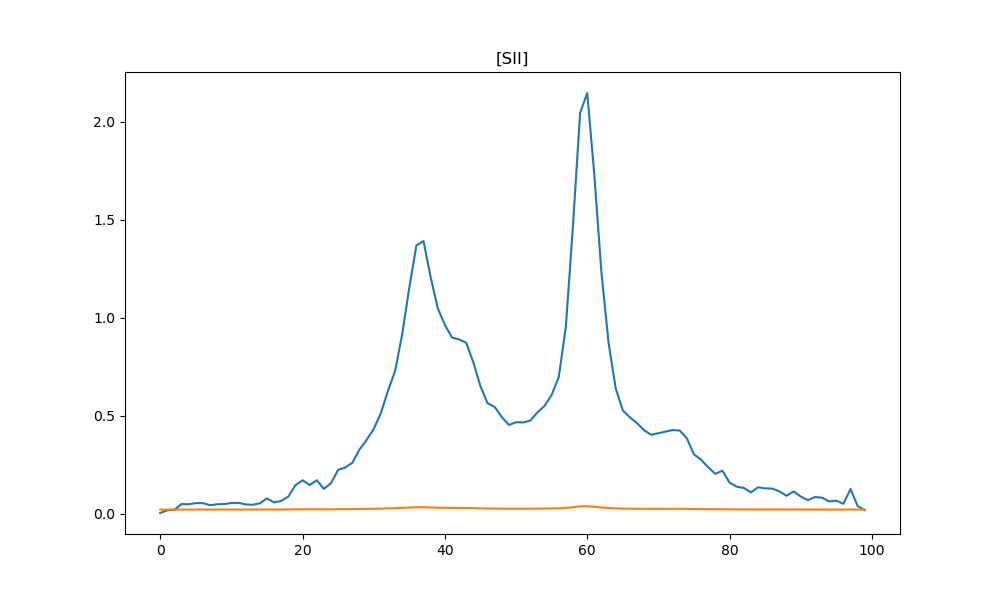

In [67]:
mask_SII = (wavelenghts > l_SII-8)*(wavelenghts < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [68]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2.4474533265135627
differential_evolution step 2: f(x)= 2.216062544647696
differential_evolution step 3: f(x)= 2.216062544647696
differential_evolution step 4: f(x)= 1.6615314228040854
differential_evolution step 5: f(x)= 1.6484922164344202
differential_evolution step 6: f(x)= 1.6484922164344202
differential_evolution step 7: f(x)= 1.5443375540791258
differential_evolution step 8: f(x)= 1.5443375540791258
differential_evolution step 9: f(x)= 1.3377986296836348
differential_evolution step 10: f(x)= 1.01718830433802
differential_evolution step 11: f(x)= 1.01718830433802
differential_evolution step 12: f(x)= 1.01718830433802
differential_evolution step 13: f(x)= 1.01718830433802
differential_evolution step 14: f(x)= 0.2897435708570963
differential_evolution step 15: f(x)= 0.2897435708570963
differential_evolution step 16: f(x)= 0.2897435708570963
differential_evolution step 17: f(x)= 0.2897435708570963
differential_evolution step 18: f(x)= 0.2897435708

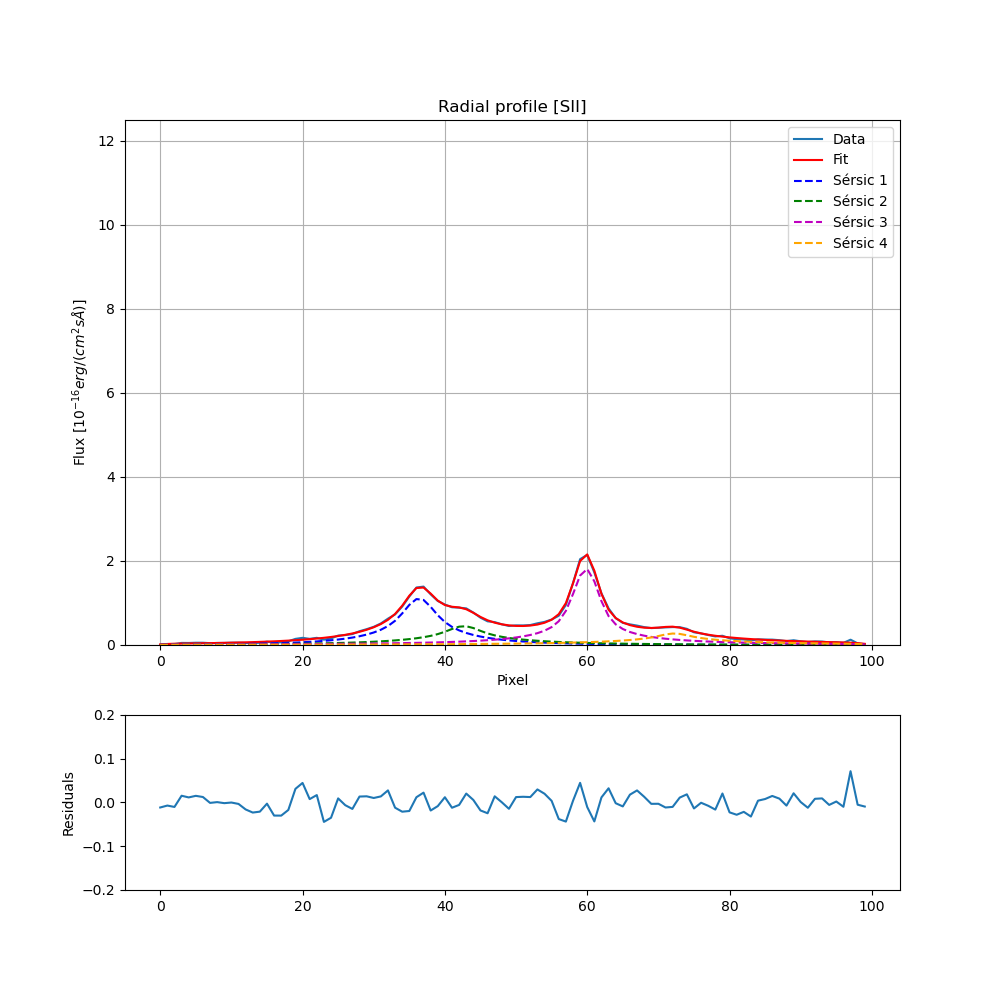

In [69]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].plot(x_axes, radial_profile_SII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')
plt.savefig('Radial_profile_SII_diff')

In [70]:
params_curve_SII, covariance_SII = curve_fit(model_convolved, x_axes, radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_SII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_SII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("SII_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_SII)))
#print(infodict.fvec**2)
chi2_SII = np.sum((((radial_profile_SII - model_convolved(x_axes, *params_curve_SII)) / radial_profile_error_SII)**2))
dof_SII = len(radial_profile_SII) - len(params_curve_SII)
chi2_reduced_SII = chi2_SII / dof_SII
print(chi2_reduced_SII)

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_8860\3240398861.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_8860\3240398861.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.0997, r_e=13.0881, n=1.6708, x_0=36.4044
Sérsic 2: I_e=0.0347, r_e=20.8974, n=1.6732, x_0=42.6611
Sérsic 3: I_e=0.0141, r_e=50.5460, n=3.7036, x_0=59.7614
Sérsic 4: I_e=0.0132, r_e=40.1508, n=1.9106, x_0=72.2140
[5.18108306e-02 7.93667290e+00 3.52118893e-01 8.07989228e-02
 5.45103443e-02 4.93322051e+01 1.04801523e+00 2.50443659e-01
 8.75805411e-02 2.55171776e+02 5.04806975e+00 4.02095939e-04
 1.29001585e-02 6.81970096e+01 6.73186391e-01 2.91367229e-01]
0.7600039815212789


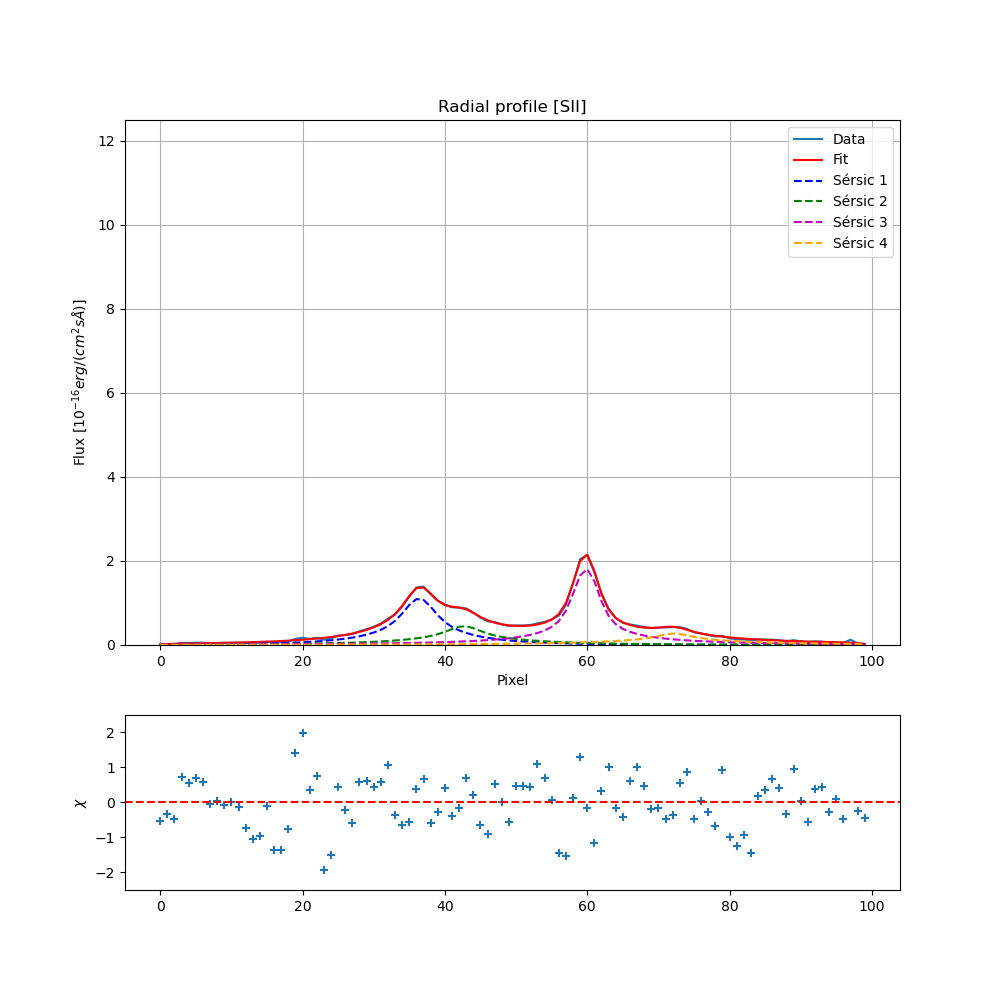

In [71]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_SII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].scatter(x_axes, (radial_profile_SII - y_fit)/radial_profile_error_SII,marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
ax[1].set_ylim(-2.5, 2.5)
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

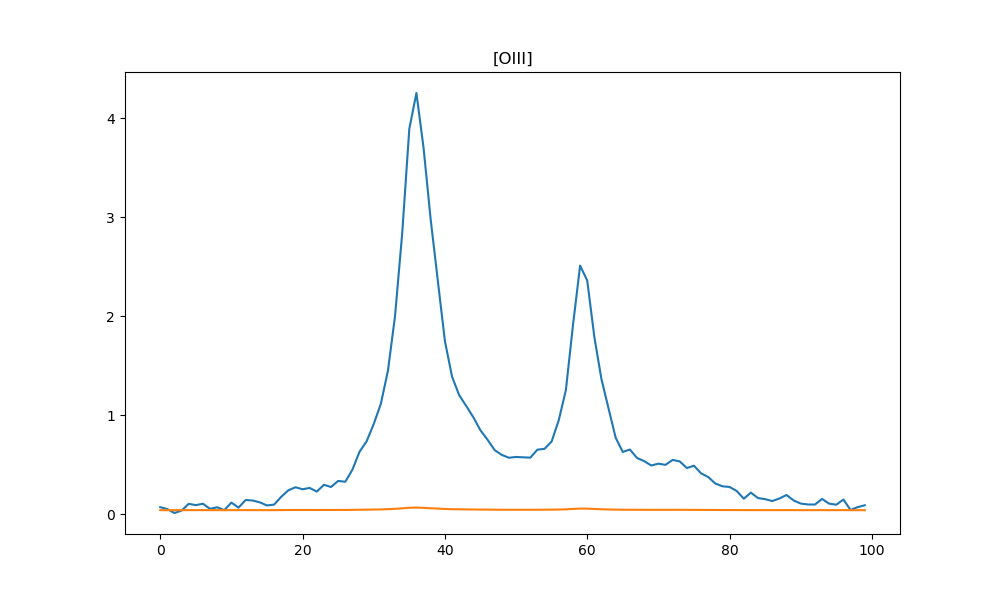

In [17]:
mask_OIII = (wavelenghts > l_OIII-8)*(wavelenghts < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [18]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 13.714595613324686
differential_evolution step 2: f(x)= 12.948224162286857
differential_evolution step 3: f(x)= 9.740167383365872
differential_evolution step 4: f(x)= 7.669122835328311
differential_evolution step 5: f(x)= 7.448267602255212
differential_evolution step 6: f(x)= 6.891742496546247
differential_evolution step 7: f(x)= 6.891742496546247
differential_evolution step 8: f(x)= 6.3814643956258745
differential_evolution step 9: f(x)= 4.618816413005704
differential_evolution step 10: f(x)= 4.618816413005704
differential_evolution step 11: f(x)= 4.618816413005704
differential_evolution step 12: f(x)= 3.6417334107767
differential_evolution step 13: f(x)= 3.6417334107767
differential_evolution step 14: f(x)= 2.4328258861055962
differential_evolution step 15: f(x)= 2.4328258861055962
differential_evolution step 16: f(x)= 2.4328258861055962
differential_evolution step 17: f(x)= 2.4328258861055962
differential_evolution step 18: f(x)= 2.43282588610559

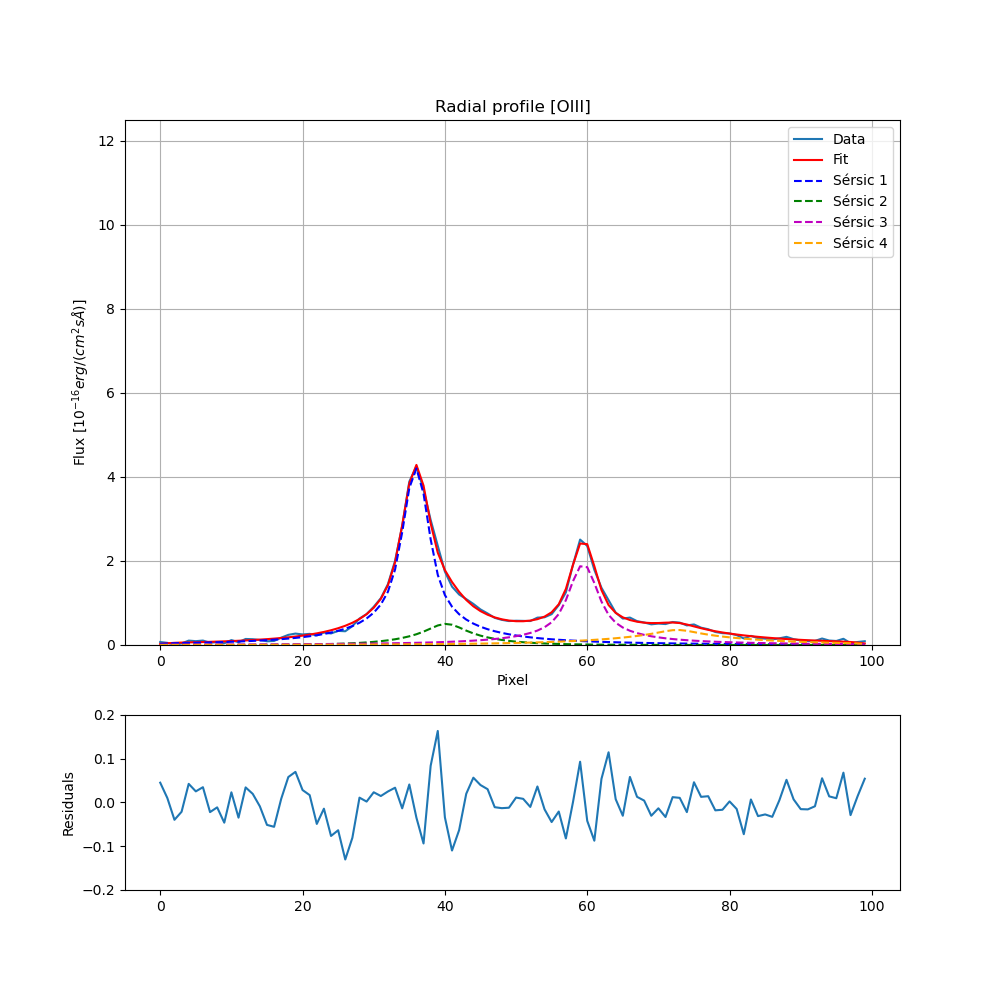

In [22]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].plot(x_axes, radial_profile_OIII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')

plt.savefig('Radial_profile_OIII_kernel')

In [20]:
params_curve_OIII, covariance_OIII = curve_fit(model_convolved, x_axes, radial_profile_OIII, p0=result.x, sigma = radial_profile_error_OIII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_OIII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_OIII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("OIII_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_OIII)))
#print(infodict.fvec**2)
chi2_OIII = np.sum((((radial_profile_OIII - model_convolved(x_axes, *params_curve_OIII)) / radial_profile_error_OIII)**2))
dof_OIII = len(radial_profile_OIII) - len(params_curve_OIII)
chi2_reduced_OIII = chi2_OIII / dof_OIII
print(chi2_reduced_OIII)

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_13352\1398174332.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_13352\1398174332.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.0971, r_e=21.3182, n=2.6650, x_0=35.8680
Sérsic 2: I_e=0.2522, r_e=6.1067, n=0.6341, x_0=38.7871
Sérsic 3: I_e=0.0281, r_e=37.3248, n=3.2199, x_0=59.4644
Sérsic 4: I_e=0.0288, r_e=32.6727, n=1.5509, x_0=72.9047
[1.17291562e-01 1.55695061e+01 8.89867579e-01 6.72173794e-02
 1.42742237e-01 1.32981235e+00 1.81121757e-01 1.76996943e+00
 1.10417066e-01 1.14767020e+02 3.33040515e+00 1.05900972e-03
 2.27671247e-02 3.57167819e+01 5.42980262e-01 4.74241412e-01]
0.9944352052217014


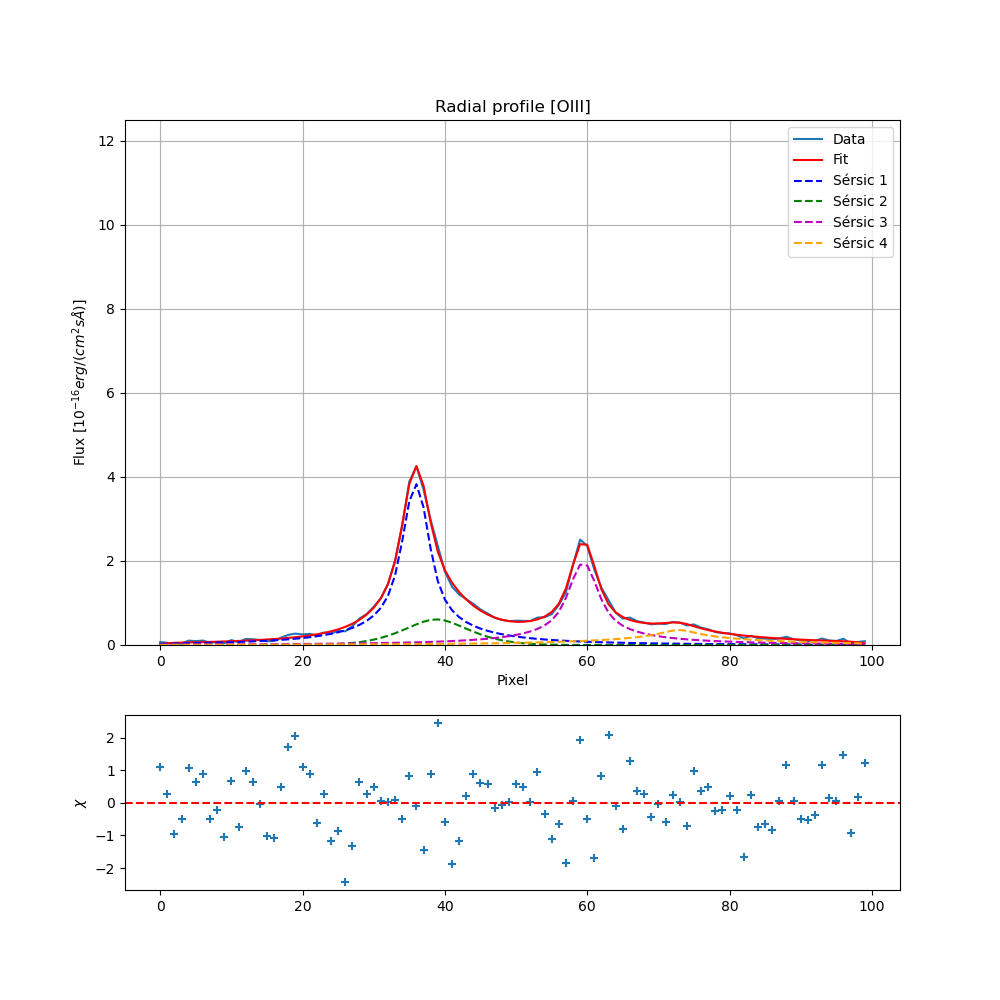

In [21]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_OIII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].scatter(x_axes, (radial_profile_OIII - y_fit)/radial_profile_error_OIII, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_OIII_curve')

In [ ]:
radial_profile_OIII - y_fit

In [78]:
radial_profile_error_OIII

array([0.0408663 , 0.04066679, 0.04039783, 0.04060245, 0.04104251,
       0.0410703 , 0.0411672 , 0.04081618, 0.04094635, 0.04063165,
       0.0412069 , 0.04090291, 0.0414317 , 0.04123707, 0.04113585,
       0.04085946, 0.04110095, 0.04156413, 0.04213136, 0.04241813,
       0.04251621, 0.04260433, 0.04224911, 0.04276725, 0.04248884,
       0.04290102, 0.04288324, 0.04371071, 0.04511561, 0.04587735,
       0.04717216, 0.04859054, 0.05085069, 0.05450951, 0.05926648,
       0.06512167, 0.06686588, 0.06399366, 0.0601399 , 0.05649621,
       0.05277004, 0.05056497, 0.04928206, 0.04852479, 0.04768422,
       0.04657831, 0.04604457, 0.04530541, 0.04510983, 0.04476442,
       0.04478256, 0.04475541, 0.04470034, 0.0453143 , 0.04523722,
       0.04581854, 0.04730725, 0.0492858 , 0.05336332, 0.05682783,
       0.05605318, 0.05256544, 0.05000076, 0.04805736, 0.04595857,
       0.04494714, 0.04513622, 0.04457861, 0.04425754, 0.04388845,
       0.04403424, 0.04397571, 0.04437908, 0.04419851, 0.04370